In [4]:
from google.colab import files
import zipfile
import io
import pandas as pd

# Esto abrirá un botón para "Elegir archivos"
uploaded = files.upload()

# Buscamos el nombre del archivo que acabas de subir
file_name = list(uploaded.keys())[0]

# Abrimos el zip directamente en memoria y leemos el CSV
with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as z:
    # Listamos los archivos dentro del zip para estar seguros del nombre
    print("Archivos dentro del zip:", z.namelist())

    # Abrimos el CSV (suponiendo que se llama credit_risk_dataset.csv)
    with z.open('credit_risk_dataset.csv') as f:
        df = pd.read_csv(f)

df.head()

Saving credit_risk_dataset.csv.zip to credit_risk_dataset.csv (1).zip
Archivos dentro del zip: ['credit_risk_dataset.csv']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


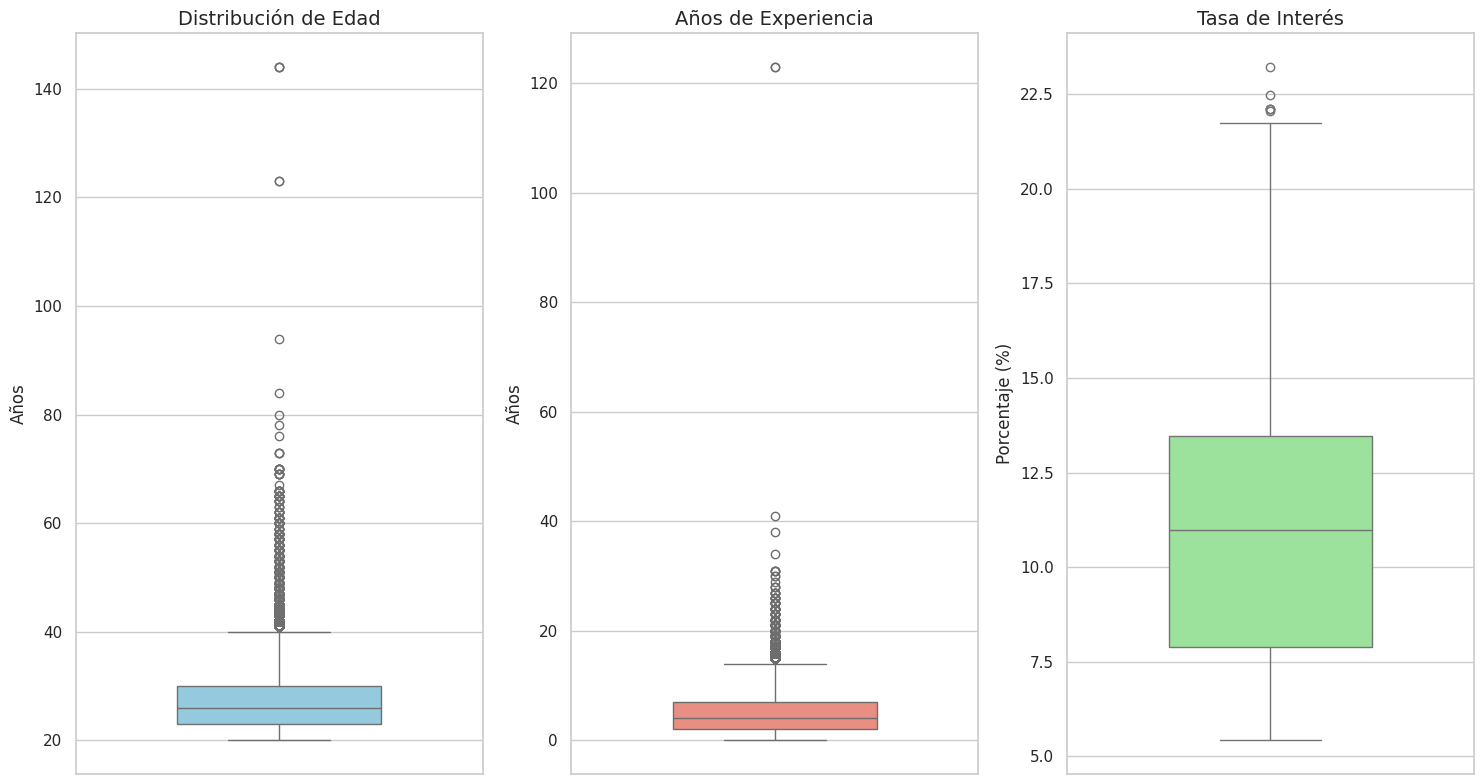

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Crear una figura con 3 subgráficos en una fila
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# 1. Boxplot de Edad (Vertical)
sns.boxplot(y=df['person_age'], ax=axes[0], color='skyblue', width=0.5)
axes[0].set_title('Distribución de Edad', fontsize=14)
axes[0].set_ylabel('Años', fontsize=12)

# 2. Boxplot de Años de Empleo (Vertical)
sns.boxplot(y=df['person_emp_length'], ax=axes[1], color='salmon', width=0.5)
axes[1].set_title('Años de Experiencia', fontsize=14)
axes[1].set_ylabel('Años', fontsize=12)

# 3. Boxplot de Tasa de Interés (Vertical)
sns.boxplot(y=df['loan_int_rate'], ax=axes[2], color='lightgreen', width=0.5)
axes[2].set_title('Tasa de Interés', fontsize=14)
axes[2].set_ylabel('Porcentaje (%)', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
# 1. Filtro de edad
df = df[df['person_age'] < 100]

# 2. Filtro de experiencia laboral
df = df[df['person_emp_length'] < 60]
df = df[df['person_emp_length'] < df['person_age']]

print(f"Limpieza completada. Registros restantes: {len(df)}")

Limpieza completada. Registros restantes: 31679


In [8]:
# Contar cuántos valores faltan en cada columna
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3047
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [9]:
# 1. Calculamos la mediana de la columna con nulos
mediana_interes = df['loan_int_rate'].median()

# 2. Rellenamos los huecos vacíos con ese valor
df['loan_int_rate'] = df['loan_int_rate'].fillna(mediana_interes)

# 3. Comprobamos que ya no hay nulos en TODO el dataset
print("Conteo de nulos por columna:")
print(df.isnull().sum())

Conteo de nulos por columna:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [10]:
# Definimos los mapas de transformación basados en tu lógica
mapeo_vivienda = {'OTHER': 0, 'RENT': 1, 'MORTGAGE': 2, 'OWN': 3}
mapeo_default = {'N': 0, 'Y': 1}
# Para loan_grade creamos un diccionario dinámico (A=1, B=2, etc.)
mapeo_grado = {letra: i+1 for i, letra in enumerate(sorted(df['loan_grade'].unique()))}

# Aplicamos los cambios
df['person_home_ownership'] = df['person_home_ownership'].map(mapeo_vivienda)
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(mapeo_default)
df['loan_grade'] = df['loan_grade'].map(mapeo_grado)

In [11]:
# Aplicamos One-Hot Encoding a la columna loan_intent
df = pd.get_dummies(df, columns=['loan_intent'], prefix='intent')

print("Nuevas columnas de intención del préstamo:")
print([col for col in df.columns if col.startswith('intent')])

Nuevas columnas de intención del préstamo:
['intent_DEBTCONSOLIDATION', 'intent_EDUCATION', 'intent_HOMEIMPROVEMENT', 'intent_MEDICAL', 'intent_PERSONAL', 'intent_VENTURE']


In [12]:
# Convertimos solo las columnas booleanas a enteros (0 y 1)
columnas_bool = df.select_dtypes(include=['bool']).columns
df[columnas_bool] = df[columnas_bool].astype(int)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 31679 entries, 1 to 32580
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31679 non-null  int64  
 1   person_income               31679 non-null  int64  
 2   person_home_ownership       31679 non-null  int64  
 3   person_emp_length           31679 non-null  float64
 4   loan_grade                  31679 non-null  int64  
 5   loan_amnt                   31679 non-null  int64  
 6   loan_int_rate               31679 non-null  float64
 7   loan_status                 31679 non-null  int64  
 8   loan_percent_income         31679 non-null  float64
 9   cb_person_default_on_file   31679 non-null  int64  
 10  cb_person_cred_hist_length  31679 non-null  int64  
 11  intent_DEBTCONSOLIDATION    31679 non-null  int64  
 12  intent_EDUCATION            31679 non-null  int64  
 13  intent_HOMEIMPROVEMENT      31679 no

/tmp/ipykernel_4135/3765453920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_status', palette='viridis')


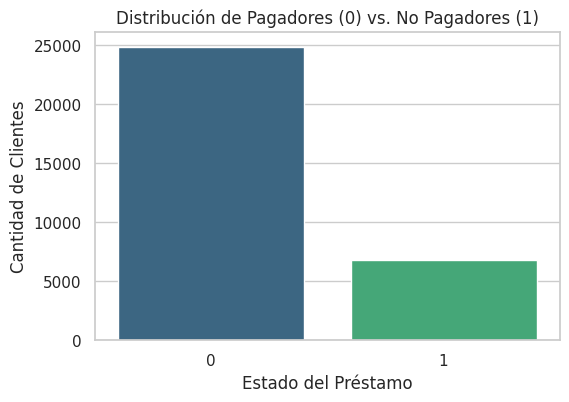

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Gráfico de barras para ver la distribución de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status', palette='viridis')

# Añadimos títulos claros
plt.title('Distribución de Pagadores (0) vs. No Pagadores (1)')
plt.xlabel('Estado del Préstamo')
plt.ylabel('Cantidad de Clientes')
plt.show()

/tmp/ipykernel_4135/1284625155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='person_income', showfliers=False, palette='Set2')


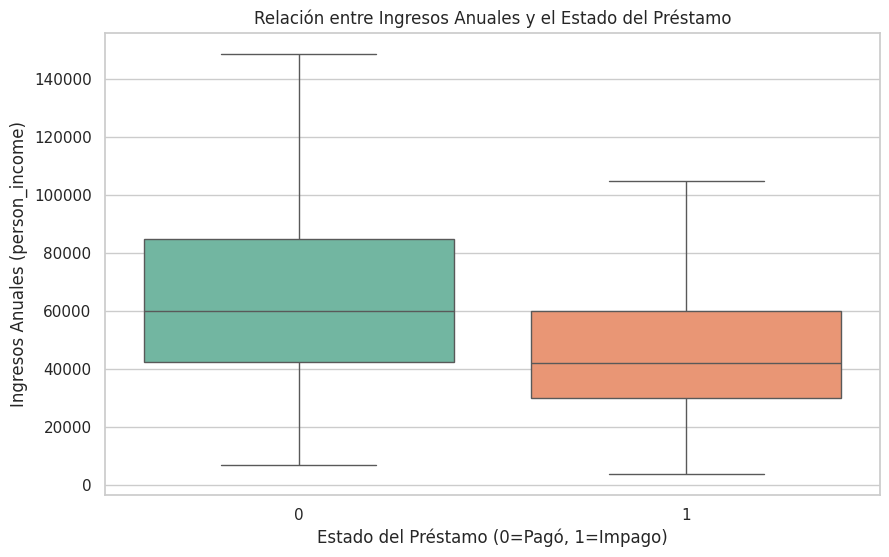

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='loan_status', y='person_income', showfliers=False, palette='Set2')

plt.title('Relación entre Ingresos Anuales y el Estado del Préstamo')
plt.xlabel('Estado del Préstamo (0=Pagó, 1=Impago)')
plt.ylabel('Ingresos Anuales (person_income)')
plt.show()

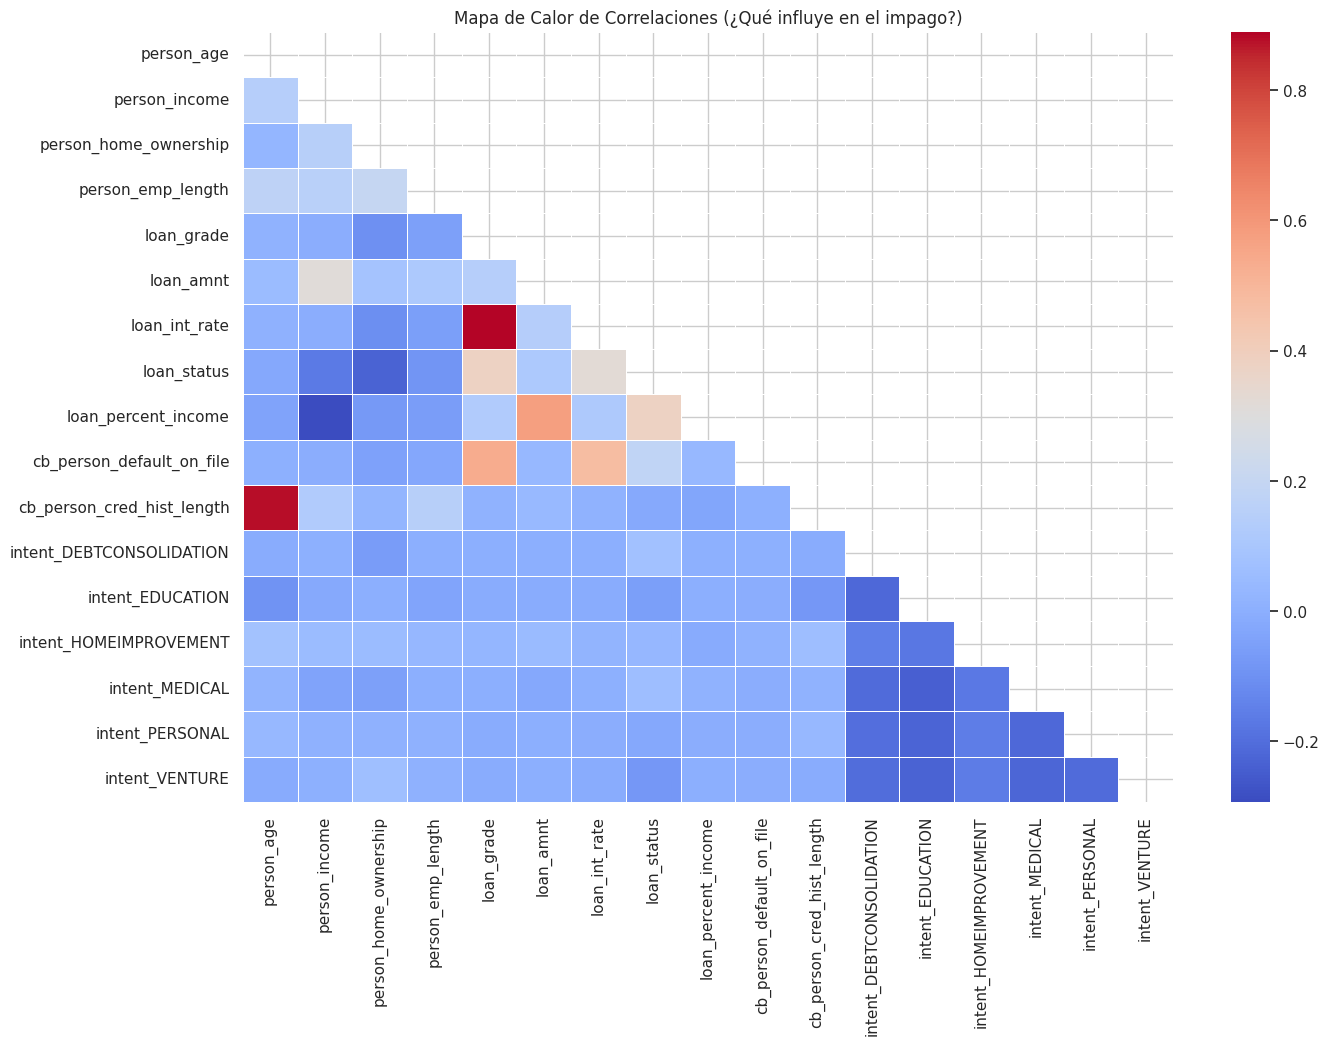

In [15]:
import numpy as np

plt.figure(figsize=(15, 10))

# Calculamos la matriz de correlación
corr = df.corr()

# Creamos una "máscara" para tapar la parte de arriba (que es espejo de la de abajo)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dibujamos el heatmap
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones (¿Qué influye en el impago?)')
plt.show()

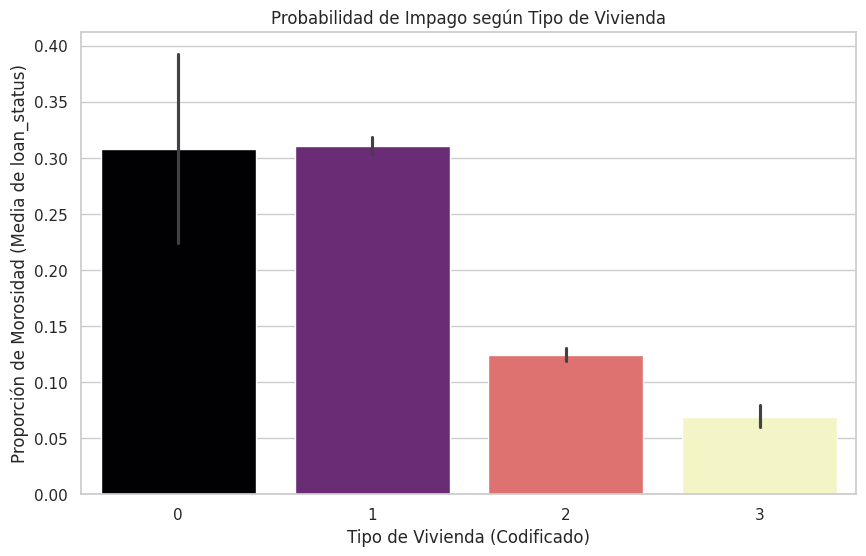

In [16]:
plt.figure(figsize=(10,6))

# Creamos un gráfico de barras que muestra el % de impagos por cada categoría de vivienda
sns.barplot(data=df, x='person_home_ownership', y='loan_status', hue='person_home_ownership', palette='magma', legend=False)

plt.title('Probabilidad de Impago según Tipo de Vivienda')
plt.xlabel('Tipo de Vivienda (Codificado)')
plt.ylabel('Proporción de Morosidad (Media de loan_status)')
plt.show()

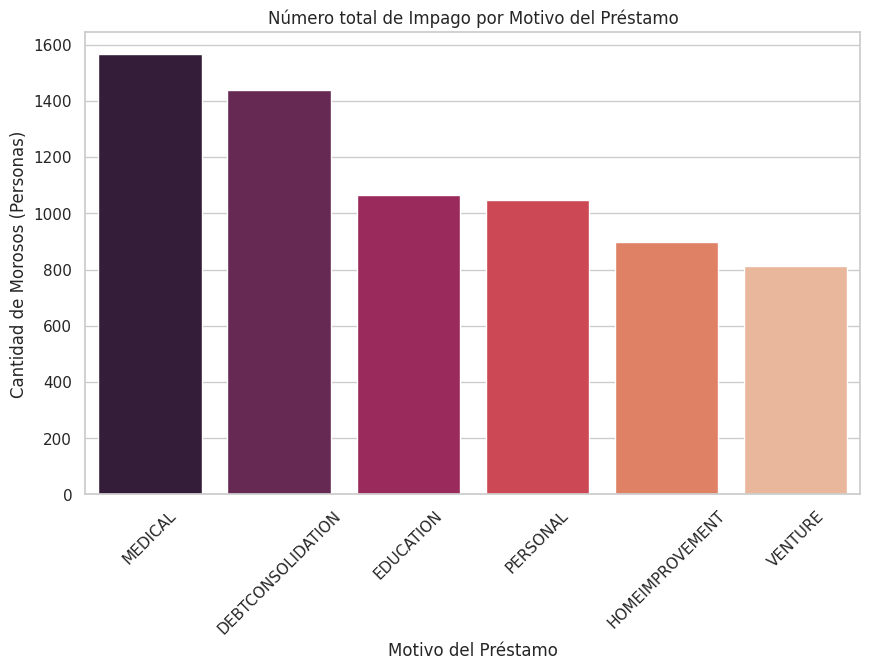

In [17]:
morosos = df[df['loan_status'] == 1]

intent_cols = [col for col in df.columns if col.startswith('intent_')]

conteo_morosos = morosos[intent_cols].sum().sort_values(ascending=False)

conteo_morosos.index = [name.replace('intent_', '') for name in conteo_morosos.index]

plt.figure(figsize=(10,6))
sns.barplot(x=conteo_morosos.index, y=conteo_morosos.values, hue=conteo_morosos.index, palette='rocket', legend=False)

plt.title('Número total de Impago por Motivo del Préstamo')
plt.ylabel('Cantidad de Morosos (Personas)')
plt.xlabel('Motivo del Préstamo')
plt.xticks(rotation=45)
plt.show()

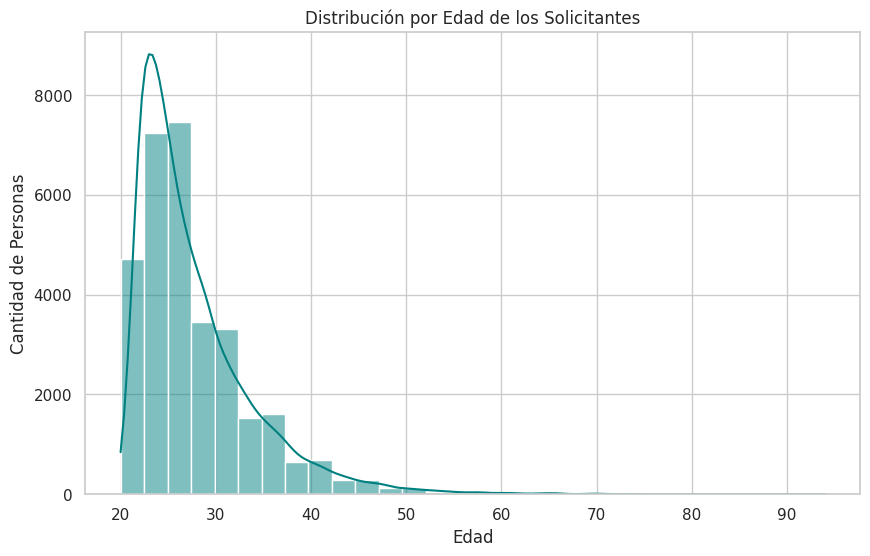

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='person_age', bins=30, kde=True, color='teal')

plt.title('Distribución por Edad de los Solicitantes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Personas')
plt.show()

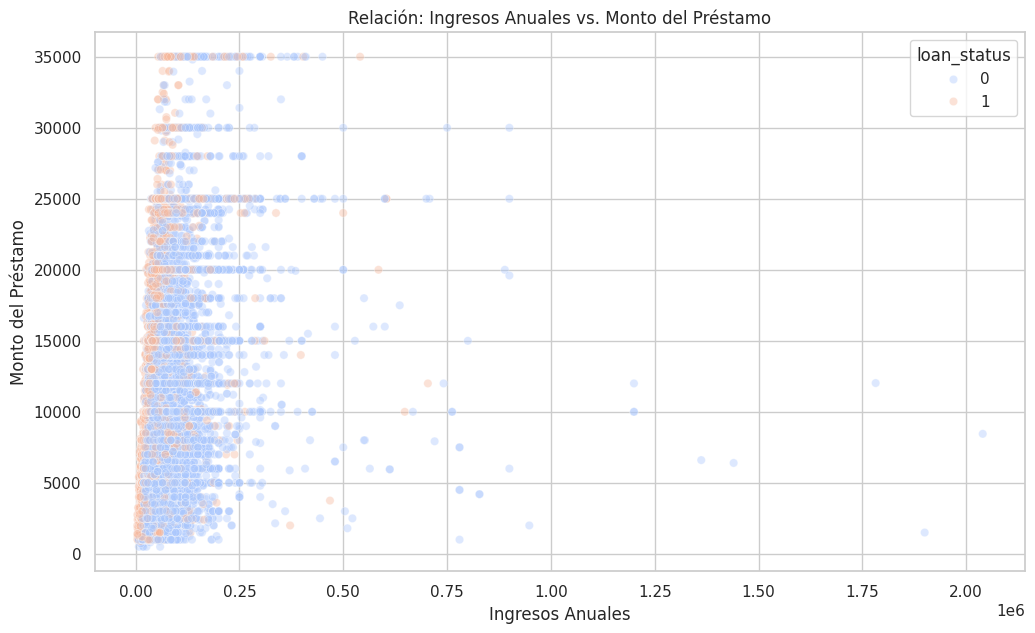

In [20]:
plt.figure(figsize=(12,7))

sns.scatterplot(data=df, x='person_income', y='loan_amnt', hue='loan_status', alpha=0.4, palette='coolwarm')

plt.title('Relación: Ingresos Anuales vs. Monto del Préstamo')
plt.xlabel('Ingresos Anuales')
plt.ylabel('Monto del Préstamo')
plt.show()

/tmp/ipykernel_4135/1006634790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', palette='viridis')


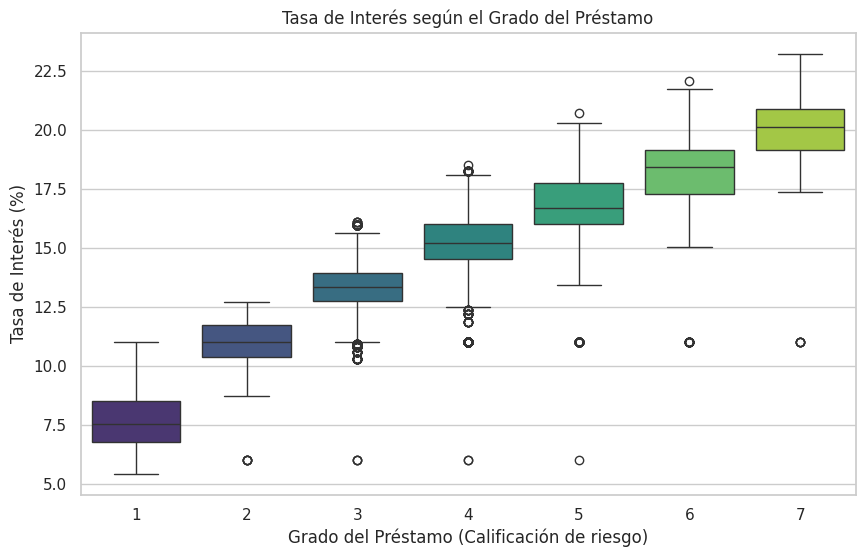

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', palette='viridis')

plt.title('Tasa de Interés según el Grado del Préstamo')
plt.xlabel('Grado del Préstamo (Calificación de riesgo)')
plt.ylabel('Tasa de Interés (%)')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df['loan_status']
X = df.drop('loan_status', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f"✅ Fase 2 completada:")
print(f"- Registros para entrenar: {X_train_scaled.shape[0]}")
print(f"- Registros para el examen: {X_test_scaled.shape[0]}")
print(f"- Número de variables procesadas: {X_train_scaled.shape[1]}")

✅ Fase 2 completada:
- Registros para entrenar: 25343
- Registros para el examen: 6336
- Número de variables procesadas: 16


In [23]:
import numpy as np

medias = np.mean(X_train_scaled, axis=0)

desviaciones = np.std(X_train_scaled, axis=0)

print("Media de las primeras 5 columnas:", np.round(medias[:5], 5))
print("Desviación de las primeras 5 columnas:", np.round(desviaciones[:5], 5))

Media de las primeras 5 columnas: [-0. -0. -0. -0. -0.]
Desviación de las primeras 5 columnas: [1. 1. 1. 1. 1.]


In [24]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

modelo_log = LogisticRegression()

modelo_log.fit(X_train_scaled, y_train)

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("✅ ¡Modelo entrenado!")
print("\nTop 5 variables que MÁS aumentan el riesgo de impago:")
print(importancias.head(5))

print("\nTop 5 variables que MÁS reducen el riesgo (clientes seguros):")
print(importancias.tail(5))

✅ ¡Modelo entrenado!

Top 5 variables que MÁS aumentan el riesgo de impago:
                    Variable  Coeficiente
7        loan_percent_income     1.363588
4                 loan_grade     1.132101
10  intent_DEBTCONSOLIDATION     0.185195
12    intent_HOMEIMPROVEMENT     0.160128
13            intent_MEDICAL     0.128095

Top 5 variables que MÁS reducen el riesgo (clientes seguros):
                 Variable  Coeficiente
14        intent_PERSONAL    -0.050476
11       intent_EDUCATION    -0.153153
15         intent_VENTURE    -0.230802
5               loan_amnt    -0.594808
2   person_home_ownership    -0.609610


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = modelo_log.predict(X_test_scaled)

# Comparamos sus respuestas con la realidad
print("--- RESULTADOS REGRESION LOGISTICA ---")
print(f"Precisión total (Accuracy): {accuracy_score(y_test, y_pred):.2%}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nInforme Detallado:")
print(classification_report(y_test, y_pred))

--- RESULTADOS REGRESION LOGISTICA ---
Precisión total (Accuracy): 85.10%

Matriz de Confusión:
[[4700  263]
 [ 681  692]]

Informe Detallado:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4963
           1       0.72      0.50      0.59      1373

    accuracy                           0.85      6336
   macro avg       0.80      0.73      0.75      6336
weighted avg       0.84      0.85      0.84      6336



In [26]:
from sklearn.ensemble import RandomForestClassifier

# Creamos y entrenamos el Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

# Testeo
y_pred_rf = modelo_rf.predict(X_test_scaled)

print("--- RESULTADOS RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print(classification_report(y_test, y_pred_rf))

--- RESULTADOS RANDOM FOREST ---
Accuracy: 93.20%
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      4963
           1       0.97      0.70      0.82      1373

    accuracy                           0.93      6336
   macro avg       0.95      0.85      0.89      6336
weighted avg       0.94      0.93      0.93      6336



In [27]:
from xgboost import XGBClassifier

# Creamos y entrenamos XGBoost
modelo_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
modelo_xgb.fit(X_train_scaled, y_train)

# Testeo
y_pred_xgb = modelo_xgb.predict(X_test_scaled)

print("--- RESULTADOS XGBOOST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
print(classification_report(y_test, y_pred_xgb))

--- RESULTADOS XGBOOST ---
Accuracy: 93.32%
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4963
           1       0.98      0.71      0.82      1373

    accuracy                           0.93      6336
   macro avg       0.95      0.85      0.89      6336
weighted avg       0.94      0.93      0.93      6336



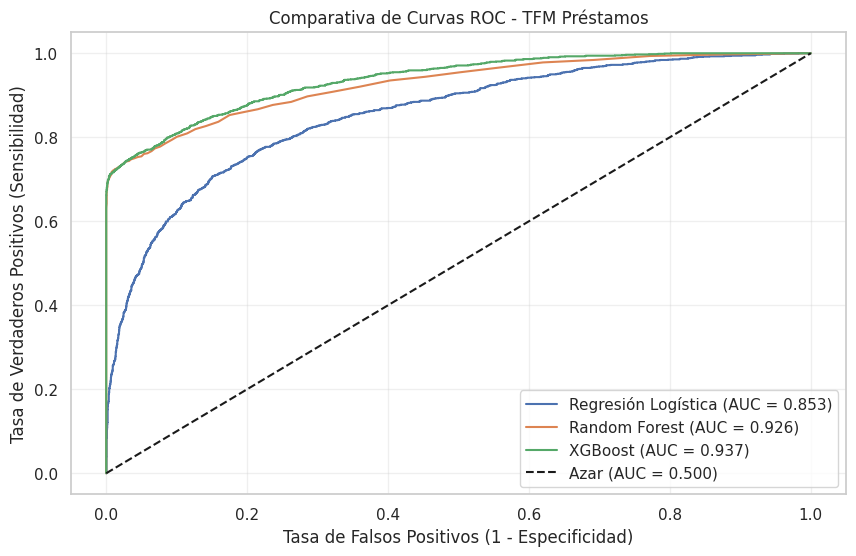

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 6))

modelos = [
    ('Regresión Logística', modelo_log, X_test_scaled),
    ('Random Forest', modelo_rf, X_test_scaled),
    ('XGBoost', modelo_xgb, X_test_scaled)
]

for nombre, modelo, X_test in modelos:
    # Obtenemos las probabilidades (necesarias para la curva ROC)
    y_probs = modelo.predict_proba(X_test)[:, 1]

    # Calculamos la curva y el AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc = roc_auc_score(y_test, y_probs)

    # Dibujamos la línea
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

# Línea diagonal de referencia (azar)
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.500)')

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Comparativa de Curvas ROC - TFM Préstamos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

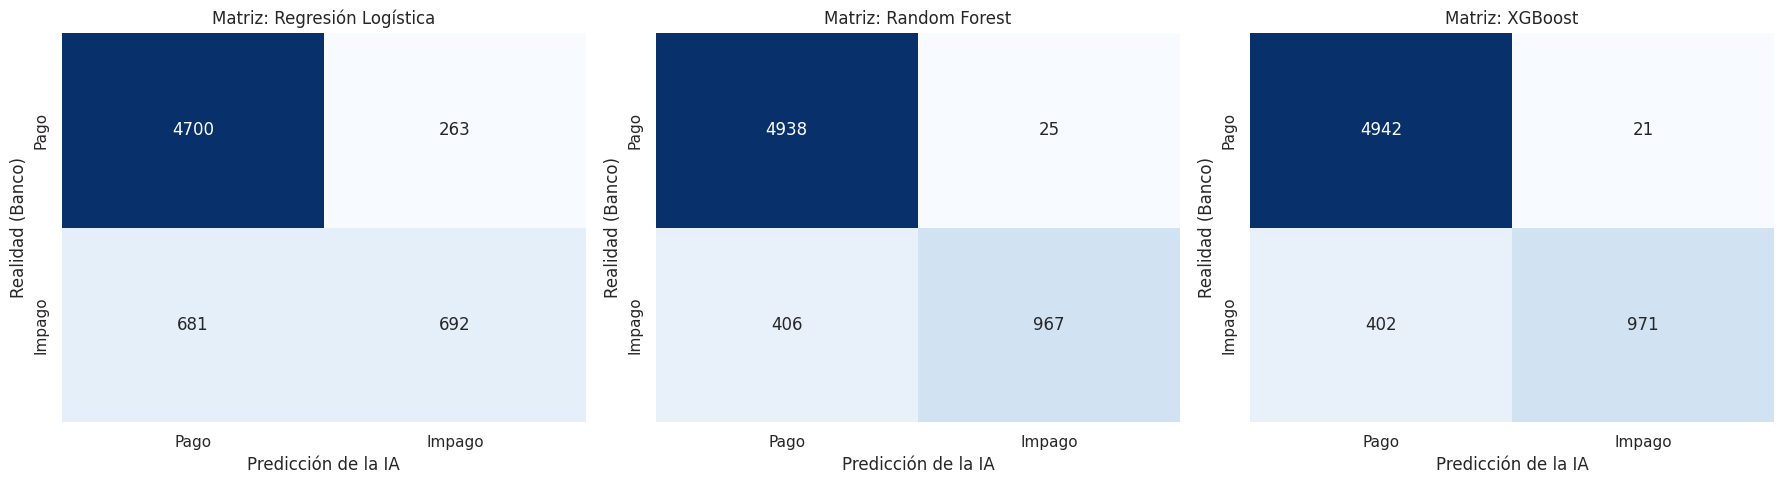

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista de modelos y sus nombres
modelos_lista = [
    ('Regresión Logística', y_pred),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (nombre, prediccion) in enumerate(modelos_lista):
    cm = confusion_matrix(y_test, prediccion)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Matriz: {nombre}')
    axes[i].set_xlabel('Predicción de la IA')
    axes[i].set_ylabel('Realidad (Banco)')
    axes[i].xaxis.set_ticklabels(['Pago', 'Impago'])
    axes[i].yaxis.set_ticklabels(['Pago', 'Impago'])

plt.tight_layout()
plt.show()

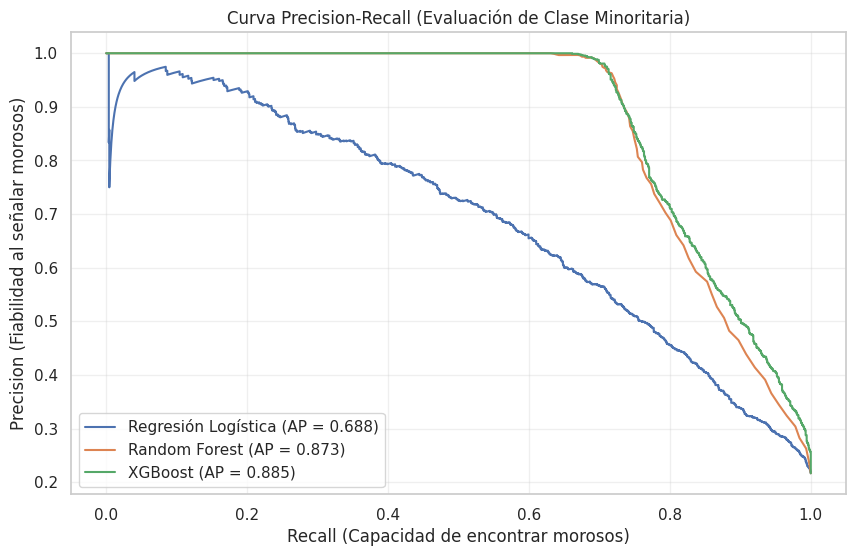

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))

for nombre, modelo, X_test in modelos:
    y_probs = modelo.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ap = average_precision_score(y_test, y_probs)

    plt.plot(recall, precision, label=f'{nombre} (AP = {ap:.3f})')

plt.xlabel('Recall (Capacidad de encontrar morosos)')
plt.ylabel('Precision (Fiabilidad al señalar morosos)')
plt.title('Curva Precision-Recall (Evaluación de Clase Minoritaria)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

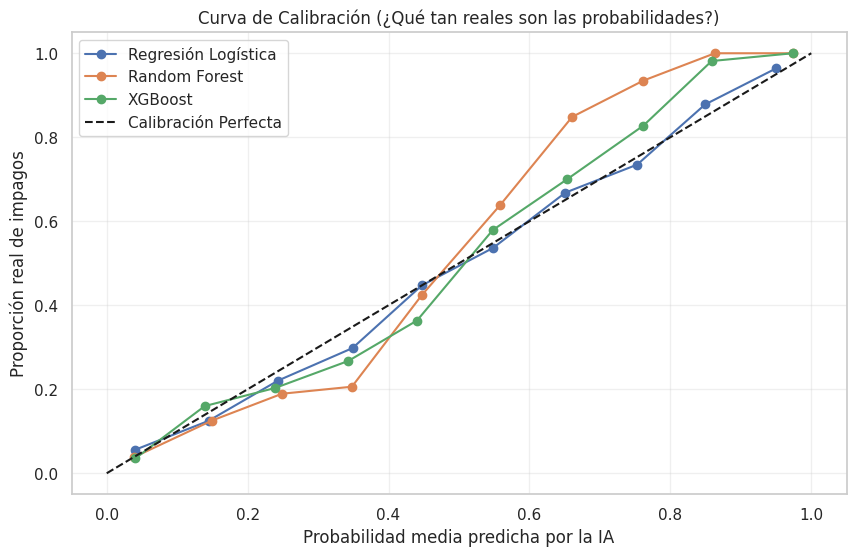

In [31]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 6))

for nombre, modelo, X_test in modelos:
    y_probs = modelo.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o', label=f'{nombre}')

# Línea de calibración perfecta
plt.plot([0, 1], [0, 1], 'k--', label='Calibración Perfecta')

plt.xlabel('Probabilidad media predicha por la IA')
plt.ylabel('Proporción real de impagos')
plt.title('Curva de Calibración (¿Qué tan reales son las probabilidades?)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

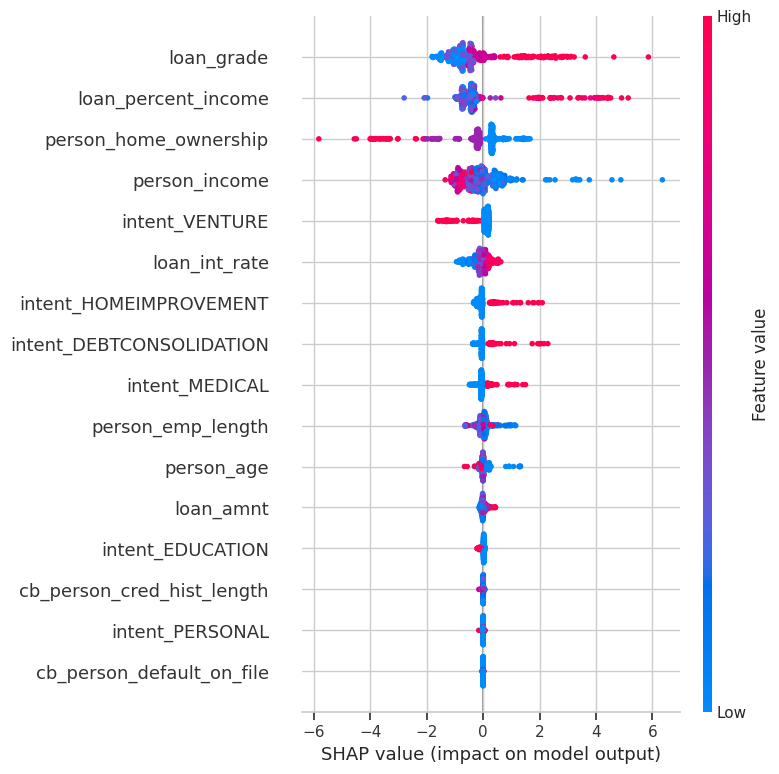

In [32]:
import shap

# Creamos el objeto explainer para XGBoost
explainer = shap.TreeExplainer(modelo_xgb)

# Calculamos los valores SHAP
X_test_sample = X_test_scaled[:500]
shap_values = explainer.shap_values(X_test_sample)

# Generamos el Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

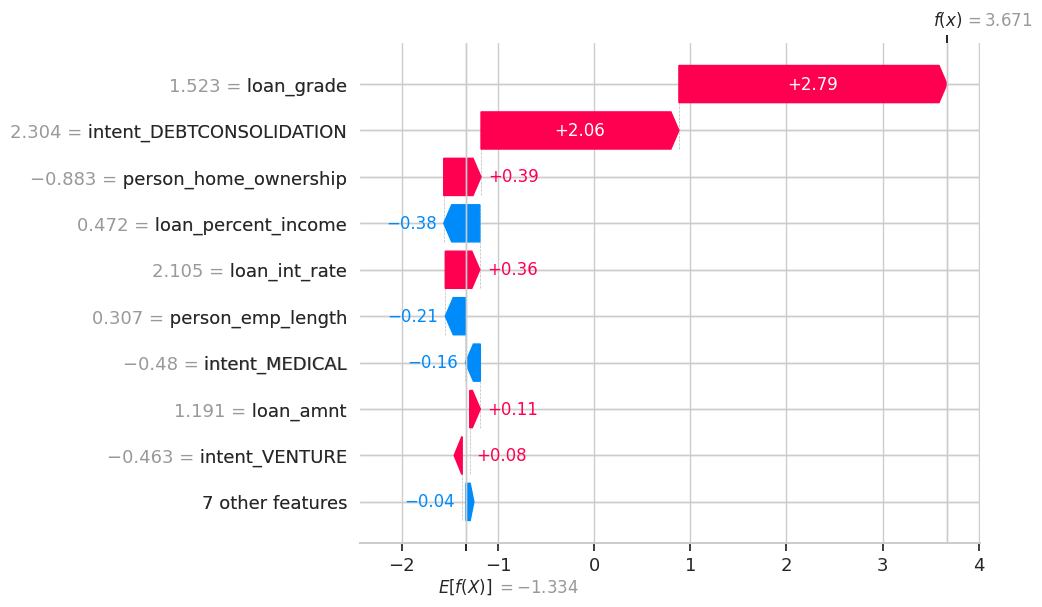

In [33]:
import pandas as pd

# Convertimos los datos escalados (X_test_scaled) en un DataFrame con nombres
X_test_con_nombres = pd.DataFrame(X_test_scaled, columns=X.columns)

# Volvemos a calcular los valores SHAP usando este nuevo DataFrame
shap_values_con_nombres = explainer(X_test_con_nombres)

# Ahora dibujamos el Waterfall Plot del cliente que quieras (ej. el número 10)
shap.plots.waterfall(shap_values_con_nombres[10], max_display=10)

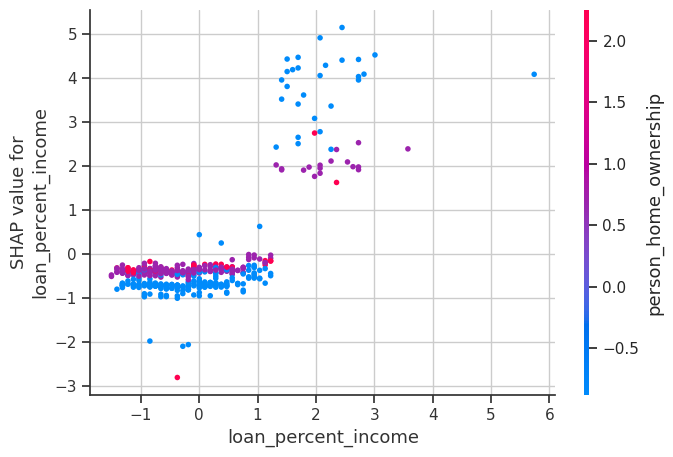

In [34]:
# Este gráfico muestra la relación exacta entre el porcentaje de ingreso y el riesgo
shap.dependence_plot("loan_percent_income", shap_values, X_test_sample, feature_names=X.columns)

In [35]:
import joblib

# Guardamos el modelo ganador y el escalador
joblib.dump(modelo_xgb, 'modelo_scoring_final.pkl')
joblib.dump(scaler, 'escalador_tfm.pkl')

print("✅ Proyecto completado y modelo exportado.")

✅ Proyecto completado y modelo exportado.
